# CMSC457 Coding: Programming in Qiskit

In this lecture, you will learn how to program in Qiskit. Your homework will be to fill in some missing pieces from this notebook.

## Setup

We start with the usual setup.

### Installing dependencies

This repository is located on GitHub [here](https://github.com/ethanlee515/cmsc457-coding-ii). The dependencies are given in ["requirements.txt"](./requirements.txt). For completeness, we describe one of the standard ways to install them:
1. Create a virtual environment: `python3 -m venv .venv`
1. Select and activate the virtual environment (follow your IDE)
1. `pip install -r requirements.txt`

### Importing dependencies

As usual, we import the libraries that we need. We also import the homework exercises. The homework must be filled in for this notebook to work properly. For the lecture, we will run this notebook using the solution key.

In [1]:
import random, itertools
import numpy, scipy
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import random_unitary

import homework as exercises

## Creating Quantum Circuits

We begin by recalling the circuit from the last coding lecture.

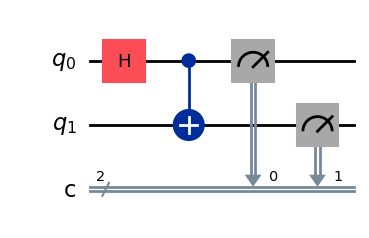

In [2]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0,1], [0,1])
qc.draw("mpl")

Recall we can simulate the circuit classically.

In [3]:
sim = AerSimulator()
result = sim.run(qc, shots=1000).result()
counts = result.get_counts()
print(counts)

{'00': 525, '11': 475}


We can then plot these results as a histogram.

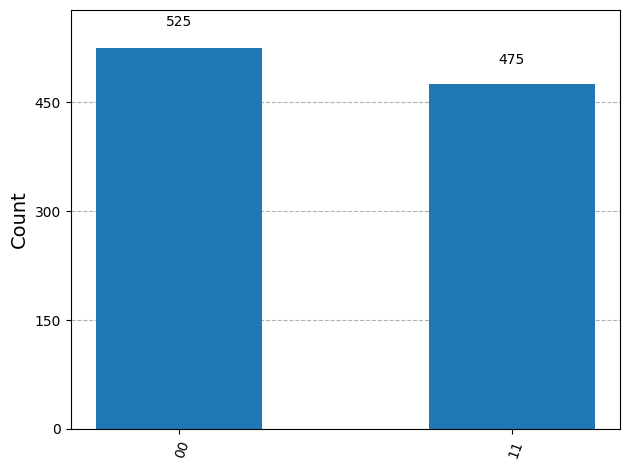

In [4]:
plot_histogram(counts)

### Exercise

Draw a circuit that does the following:
1. Create a GHZ state $\frac{1}{\sqrt 2}(\ket{000} + \ket{111})$
2. Flip the first qubit and get $\frac{1}{\sqrt 2}(\ket{100} + \ket{011})$
3. Measure everything

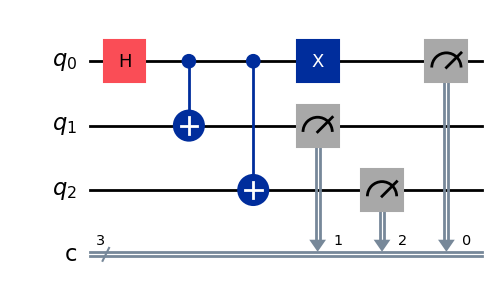

In [5]:
exercises.ghz_x_meas().draw("mpl")

Let's simulate the circuit too! Notice anything strange?

In [6]:
sim = AerSimulator()
result = sim.run(exercises.ghz_x_meas(), shots=1000).result()
counts = result.get_counts()
print(counts)

{'110': 527, '001': 473}


The first qubit is the _rightmost_ one. This is called the _little endian_ bit order. The least significant bit is the first one.

## Superdense Coding

Let's recall the settings of Superdense coding.
There are two players: Alice and Bob.
1. Alice and Bob each hold one half of an EPR pair.
1. Alice wants to send two classical bits $(x, z)$ to Bob, but she can only send one qubit.
1. Alice operates on her half of EPR and sends it to Bob
1. Bob decodes his two qubits to recover $(x', z')$.

Denote the EPR pair as $\ket{\Phi^+}=\ket{00}+\ket{11}$, and consider the circuit for preparing EPR pairs $U=\mathsf{CNOT}\circ\mathsf{H}_1$.
Recall we have the following:
$$\begin{align*}
U\ket{00}&=\ket{00}+\ket{11}\\&=\ket{\Phi^+} \\
U\ket{01}&=\ket{01}+\ket{10}\\&=(\mathsf{X}\otimes\mathsf{I})\ket{\Phi^+} \\
U\ket{10}&=\ket{00}-\ket{11}\\&=(\mathsf{Z}\otimes\mathsf{I})\ket{\Phi^+} \\
U\ket{11}&=\ket{01}-\ket{10}\\&=-(\mathsf{XZ}\otimes\mathsf{I})\ket{\Phi^+}
\end{align*}$$

This shows that Alice should encode her qubit by applying $X^xZ^z$.
Bob should decode the result by applying $U^\dag$ and then measuring the result.
Based on the calculations above, Bob's measurement outcome will be $(z, x)$

Alice's actions is left as an exercise.

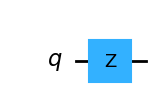

In [7]:
exercises.superdense_alice(0, 1).draw("mpl")

Bob's operations will be a homework exercise as well.

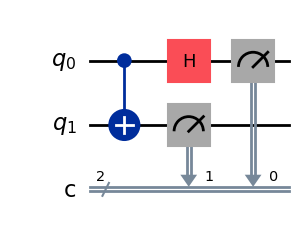

In [8]:
exercises.superdense_bob().draw("mpl")

Let's put the entire experiment together.

In [9]:
def superdense(x, z):
  qc = QuantumCircuit(2, 2)
  # prepare EPRs
  qc.h(0)
  qc.cx(0, 1)
  # operations
  qc.barrier()
  qc.compose(
    exercises.superdense_alice(x, z),
    [0], inplace=True)
  qc.barrier()
  qc.compose(
    exercises.superdense_bob(),
    [0, 1], [0, 1], inplace=True)
  return qc

Let's look at the entire experiment. See if the circuit looks right.

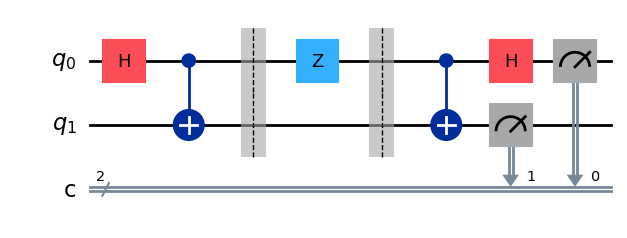

In [10]:
superdense_01 = superdense(0, 1)
superdense_01.draw("mpl")

Now, let's simulate the circuit and check if the result is correct.

In [11]:
sim = AerSimulator()
result = sim.run(superdense_01, shots=1000).result()
counts = result.get_counts()
print(counts)

{'01': 1000}


The measurement outcome $01$ corresponds to $(1, 0)$ due to the little-endian bit order.
That is, $z=1$ and $x=0$.
Finally, we can check if things are correct for all inputs $(x, z)$.

In [12]:
for xz in ["00", "01", "10", "11"]:
  (x, z) = map(int, xz)
  sim = AerSimulator()
  result = sim.run(superdense(x, z), shots=1000).result()
  counts = result.get_counts()
  assert(list(counts.keys()) == [xz])

## Quantum Teleportation

Recall the setting of quantum teleportation. Alice has an input $\ket{\psi}$ that she wants to send to Bob. Alice and Bob share an EPR pair, but Alice can only send classical information. The experiment is as follows.
1. Aice and Bob share an EPR pair.
1. Alice applies the operation $\mathsf{H}_1\circ\mathsf{CNOT}$ and then measure her qubits to get the outcome $(z, x)$. She sends $(z, x)$ to Bob.
1. Given $(z, x)$, Bob applies $X^xZ^z$ on his half of the EPR pair.

Note that for circuit compositions involving classical controls, Qiskit seems to require well-defined registers. We present Bob's operations as an example.

In [13]:
def teleport_bob(qreg: QuantumRegister, creg: ClassicalRegister):
  assert len(qreg) == 1
  assert len(creg) == 2
  qc = QuantumCircuit(qreg, creg)
  with qc.if_test((creg[0], 1)):
    qc.z(qreg[0])
  with qc.if_test((creg[1], 1)):
    qc.x(qreg[0])
  return qc

As before, we draw the circuit and check if it looks right.

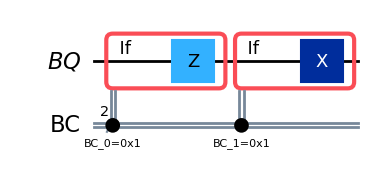

In [14]:
qreg = QuantumRegister(1, name="BQ")
creg = ClassicalRegister(2, name="BC")
teleport_bob(qreg, creg).draw("mpl")

We leave Alice's operations as another homework exercise.

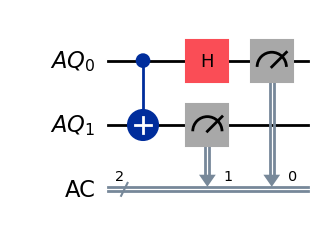

In [15]:
qreg = QuantumRegister(2, name="AQ")
creg = ClassicalRegister(2, name="AC")
exercises.teleport_alice(qreg, creg).draw("mpl")

Before writing down the entire experiment, we need to define all the registers.

In [16]:
qubits = QuantumRegister(3, name="TeleQ")
alice_qubits = qubits[0:2]
bob_qubits = qubits[2:]
alice_meas = ClassicalRegister(2, name="AM")
# Check if the teleportation result matches Alice's input
success = ClassicalRegister(1, name="success")

Note that Bob holds a 1-qubit _register_ which we defined by _slicing_. Qiskit treats it as a different type from one single qubit.

In [17]:
print(f"reg type = {type(qubits[2:])}, index type = {type(qubits[2])}")

reg type = <class 'list'>, index type = <class 'qiskit.circuit.Qubit'>


Now we are ready to put the entire teleportation experiment together.

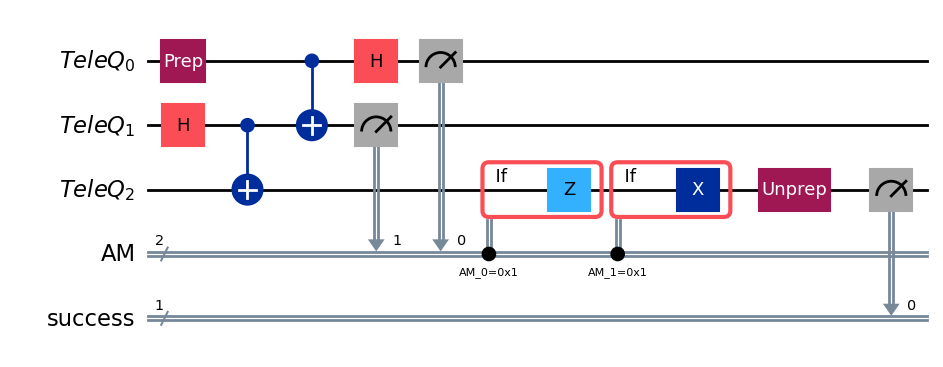

In [18]:
teleport = QuantumCircuit(qubits, alice_meas, success)
# prepare EPR
teleport.h(qubits[1])
teleport.cx(qubits[1], qubits[2])
# prepare random input for Alice
U = random_unitary(2)
teleport.unitary(U, qubits[0], label="Prep")
# teleport
teleport.compose(
  exercises.teleport_alice(alice_qubits, alice_meas),
  alice_qubits, alice_meas, inplace=True)
teleport.compose(
  teleport_bob(bob_qubits, alice_meas),
  bob_qubits, alice_meas, inplace=True)
# Checking if the output is U\ket{0}.
# Here we undo U and measure, hoping to get \ket{0}.
teleport.unitary(U.adjoint(), [2], label="Unprep")
teleport.measure(qubits[2], success)

teleport.draw("mpl")

We simulate the circuit a few times, and observe that the `out` bit is always 0. We also observe that the teleportation correction (`alice_meas`) is uniformly random as expected.

In [19]:
sim = AerSimulator()
result = sim.run(teleport, shots=1000).result()
counts = result.get_counts()
print(counts)

{'0 01': 228, '0 00': 264, '0 11': 262, '0 10': 246}


## Entanglement Swapping

There are no new building blocks required for entanglement swapping.
Instead, all of the quantum operations will be homework exercise.

### Setting

There are three players: Alice, Bob, and Charlie.
* Alice and Bob want to share an EPR pair, but they cannot communicate with each other
* Alice and Charlie share an EPR pair and can communicate classically
* Bob and Charlie share an EPR pair

### Theory Reminder

Here is a sketch of the protocol and its analysis.
1. Suppose we have two EPR pairs in 4 qubits.
   Qubit 1 belongs to Alice, qubits 2 and 3 belongs to Charlie, and qubit 4 belongs to Bob.
1. Charlie apply $\mathsf{CNOT}$ then $\mathsf{H}_1$ on his qubits: $$
\begin{align*}
(\ket{00}+\ket{11})\otimes(\ket{00}+\ket{11})&=\ket{0000}+\ket{0011}+\ket{1100}+\ket{1111}\\
\mathsf{CNOT}_{23}&\mapsto\ket{0000}+\ket{0011}+\ket{1110}+\ket{1101}\\
\mathsf{H}_2&\mapsto\ket{0000}+\ket{0100}+\ket{0011}+\ket{0111}\\
&\qquad+\ket{1010}-\ket{1110}+\ket{1001}-\ket{1101}\\
&=(\ket{0000}+\ket{1001})+(\ket{0011}+\ket{1010})\\
&\qquad+(\ket{0100}-\ket{1101})+(\ket{0111}-\ket{1110})\\
\textnormal{relabel}&\mapsto\ket{00}\otimes(\ket{00}+\ket{11})+\ket{01}\otimes(\ket{01}+\ket{10})\\
&\qquad+\ket{10}\otimes(\ket{00}-\ket{11})+\ket{11}\otimes(\ket{01}-\ket{10})\\
&=\ket{00}\otimes\ket{\Phi^+}+\ket{01}\otimes(\mathsf{X}_1\ket{\Phi^+})\\
&\qquad+\ket{10}\otimes(\mathsf{Z}_1\ket{\Phi^+})-\ket{11}\otimes(\mathsf{X}_1\mathsf{Z}_1\ket{\Phi^+})
\end{align*}$$
1. Charlie measures his qubits and send the results to Alice.
   At this point, with the measurement outcome being $m$, the state is: $$\ket{\psi^{AB}}=\begin{cases}
			\ket{\Phi^+} & m=00 \\
			\mathsf{X}_1\ket{\Phi^+} & m=01 \\
			\mathsf{Z}_1\ket{\Phi^+} & m = 10 \\
			\mathsf{X}_1\mathsf{Z}_1\ket{\Phi^+} & m = 11
	 \end{cases}$$
1. Alice maps the state to an EPR pair

First, Charlie's operations are left as an exercise.

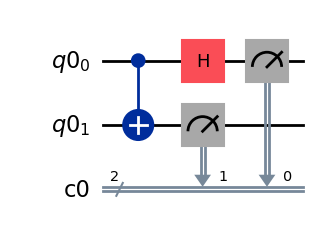

In [20]:
qreg = QuantumRegister(2)
creg = ClassicalRegister(2)
exercises.swap_charlie(qreg, creg).draw("mpl")

Alice's operations are left as an exercise as well.

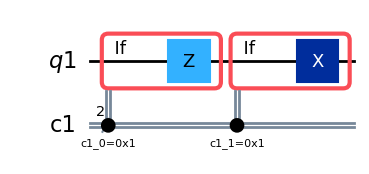

In [21]:
qreg = QuantumRegister(1)
creg = ClassicalRegister(2)
exercises.swap_alice(qreg, creg).draw("mpl")

Now, let's do the entire experiment as before.

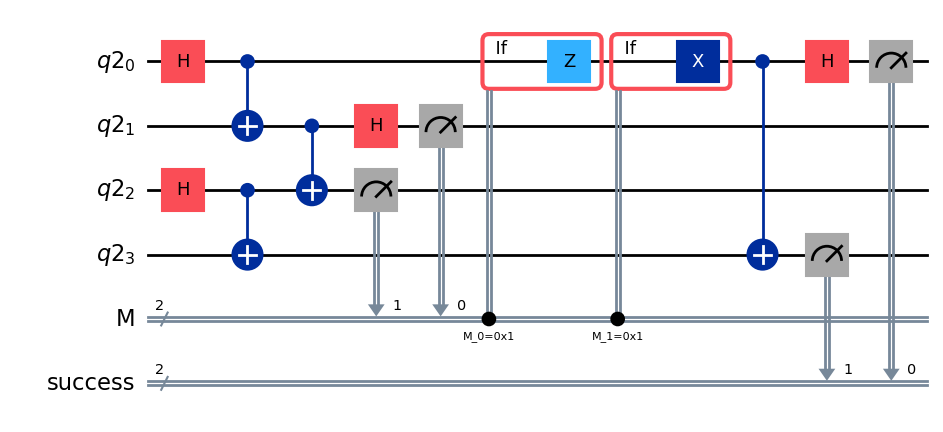

In [22]:
def entanglement_swap():
  qubits = QuantumRegister(4)
  alice_qubits = qubits[0:1]
  charlie_qubits = qubits[1:3]
  charlie_meas = ClassicalRegister(2, name="M")
  # Check if the result is an EPR
  success = ClassicalRegister(2, name="success")
  qc = QuantumCircuit(qubits, charlie_meas, success)
  # prepare EPR
  qc.h(qubits[0])
  qc.cx(qubits[0], qubits[1])
  qc.h(qubits[2])
  qc.cx(qubits[2], qubits[3])
  # players' operations
  qc.compose(
    exercises.swap_charlie(charlie_qubits, charlie_meas),
    charlie_qubits, charlie_meas, inplace=True)
  qc.compose(
    exercises.swap_alice(alice_qubits, charlie_meas),
    alice_qubits, charlie_meas, inplace=True)
  # Checking if the output is an EPR.
  # Equivalently, we undo the EPR and measure, hoping to get \ket{00}.
  qc.cx(qubits[0], qubits[3])
  qc.h(qubits[0])
  qc.measure([qubits[0], qubits[3]], success)
  return qc

entanglement_swap().draw("mpl")

Finally, we experiment as before.

In [23]:
sim = AerSimulator()
result = sim.run(entanglement_swap(), shots=1000).result()
counts = result.get_counts()
print(counts)

{'00 11': 254, '00 00': 231, '00 01': 281, '00 10': 234}


## Five Qubit Code

If time allows, we will cover Homework 4, Problem 4.
That is, given a Pauli operator, we want to measure with respect to its eigenspaces.
Our goal is to eventually build towards the following error correction experiment:
1. Start with a random state $\ket{\phi}$
1. Encode it into $\ket{\tilde{\phi}}$ using the 5-qubit code
1. Apply a single-qubit error $A^*$.
1. Measure the error syndrome and apply the corresponding correction
1. Decode the error-correcting code to obtain $\ket{\phi'}$
1. Check if we recover the initial state $\ket{\phi'}=\ket{\phi}$

First, we have the following expression from the homework.
$$\begin{align*}
\ket{0_L}&=\frac{1}{4}(\ket{00000}\\
&\qquad+\ket{10010}+\ket{01001}+\ket{10100}+\ket{01010}+\ket{00101}\\
&\qquad-\ket{11000}-\ket{01100}-\ket{00110}-\ket{00011}-\ket{10001}\\
&\qquad-\ket{01111}-\ket{10111}-\ket{11011}-\ket{11101}-\ket{11110})
\end{align*}$$

$$\begin{align*}
\ket{1_L}&=\frac{1}{4}(\ket{11111}\\
&\qquad+\ket{01101}+\ket{10110}+\ket{01011}+\ket{10101}+\ket{11010}\\
&\qquad-\ket{00111}-\ket{10011}-\ket{11001}-\ket{11100}-\ket{01110}\\
&\qquad-\ket{10000}-\ket{01000}-\ket{00100}-\ket{00010}-\ket{00001})
\end{align*}$$

We transcribe these two states into Python.

In [24]:
terms0 = [
  "+00000",
  "+10010", "+01001", "+10100", "+01010", "+00101",
  "-11000", "-01100", "-00110", "-00011", "-10001",
  "-01111", "-10111", "-11011", "-11101", "-11110"]

terms1 = [
  "+11111",
  "+01101", "+10110", "+01011", "+10101", "+11010",
  "-00111", "-10011", "-11001", "-11100", "-01110",
  "-10000", "-01000", "-00100", "-00010", "-00001"]

We convert them to vectors. Nothing interesting here yet; just some boilerplate parsing.

In [25]:
def parse(s):
  sgn = (1 if s[0] == "+" else -1)
  val = int("".join(reversed(s[1:])), 2) # little endian
  mag = numpy.eye(32)[val]
  return sgn * mag

ket0L = numpy.sum([parse(s) for s in terms0], axis=0) / 4
ket1L = numpy.sum([parse(s) for s in terms1], axis=0) / 4
print(ket0L)

[ 0.25  0.    0.   -0.25  0.    0.25 -0.25  0.    0.    0.25  0.25  0.
 -0.25  0.    0.   -0.25  0.   -0.25  0.25  0.    0.25  0.    0.   -0.25
 -0.25  0.    0.   -0.25  0.   -0.25 -0.25  0.  ]


Now, the actual encoding circuit in general is tricky to write down.
Instead, we aim to write down just a 5-qubit unitary matrix $\mathcal{E}$ with the right mapping:
$$\begin{align*}
\ket{00000}&\mapsto\ket{0_L}\\
\ket{10000}&\mapsto\ket{1_L}
\end{align*}$$
That is, we want column 0 of $\mathcal{E}$ to contain $\ket{0_L}$.
Due to little-endian bit ordering, we place $\ket{1_L}$ on the $\underline{00001}_2=1$-st column of $\mathcal{E}$.
For $\mathcal{E}$ to be unitary, we fill in the other columns in a way that they form an orthonormal basis.

In [26]:
other_cols = scipy.linalg.null_space([ket0L, ket1L])
qec_encode = numpy.hstack([
  ket0L.reshape(32, 1),
  ket1L.reshape(32, 1),
  other_cols])

qec_decode = qec_encode.conjugate().T

The syndrome measurement circuit comes from homework 4, part 5. We leave it as a programming homework exercise as well.

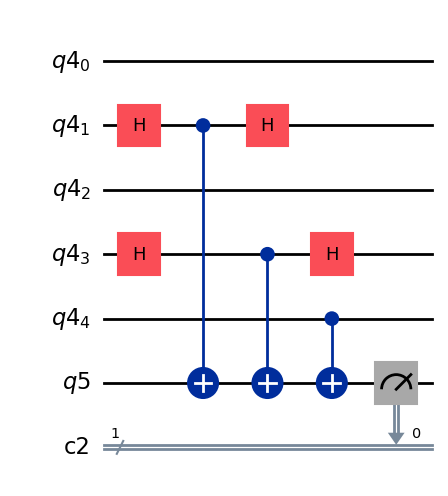

In [27]:
data = QuantumRegister(5)
ancilla = QuantumRegister(1)
creg = ClassicalRegister(1)
exercises.measure_one_syndrome(data, ancilla, creg, "IXIXZ").draw("mpl")


Now we can measure all the syndromes. For reference, here is the list of stabilizers.
$$X\otimes Z\otimes Z\otimes X\otimes I$$
$$I\otimes X\otimes Z\otimes Z\otimes X$$
$$X\otimes I\otimes X\otimes Z\otimes Z$$
$$Z\otimes X\otimes I\otimes X\otimes Z$$
$$Z\otimes Z\otimes X\otimes I\otimes X$$

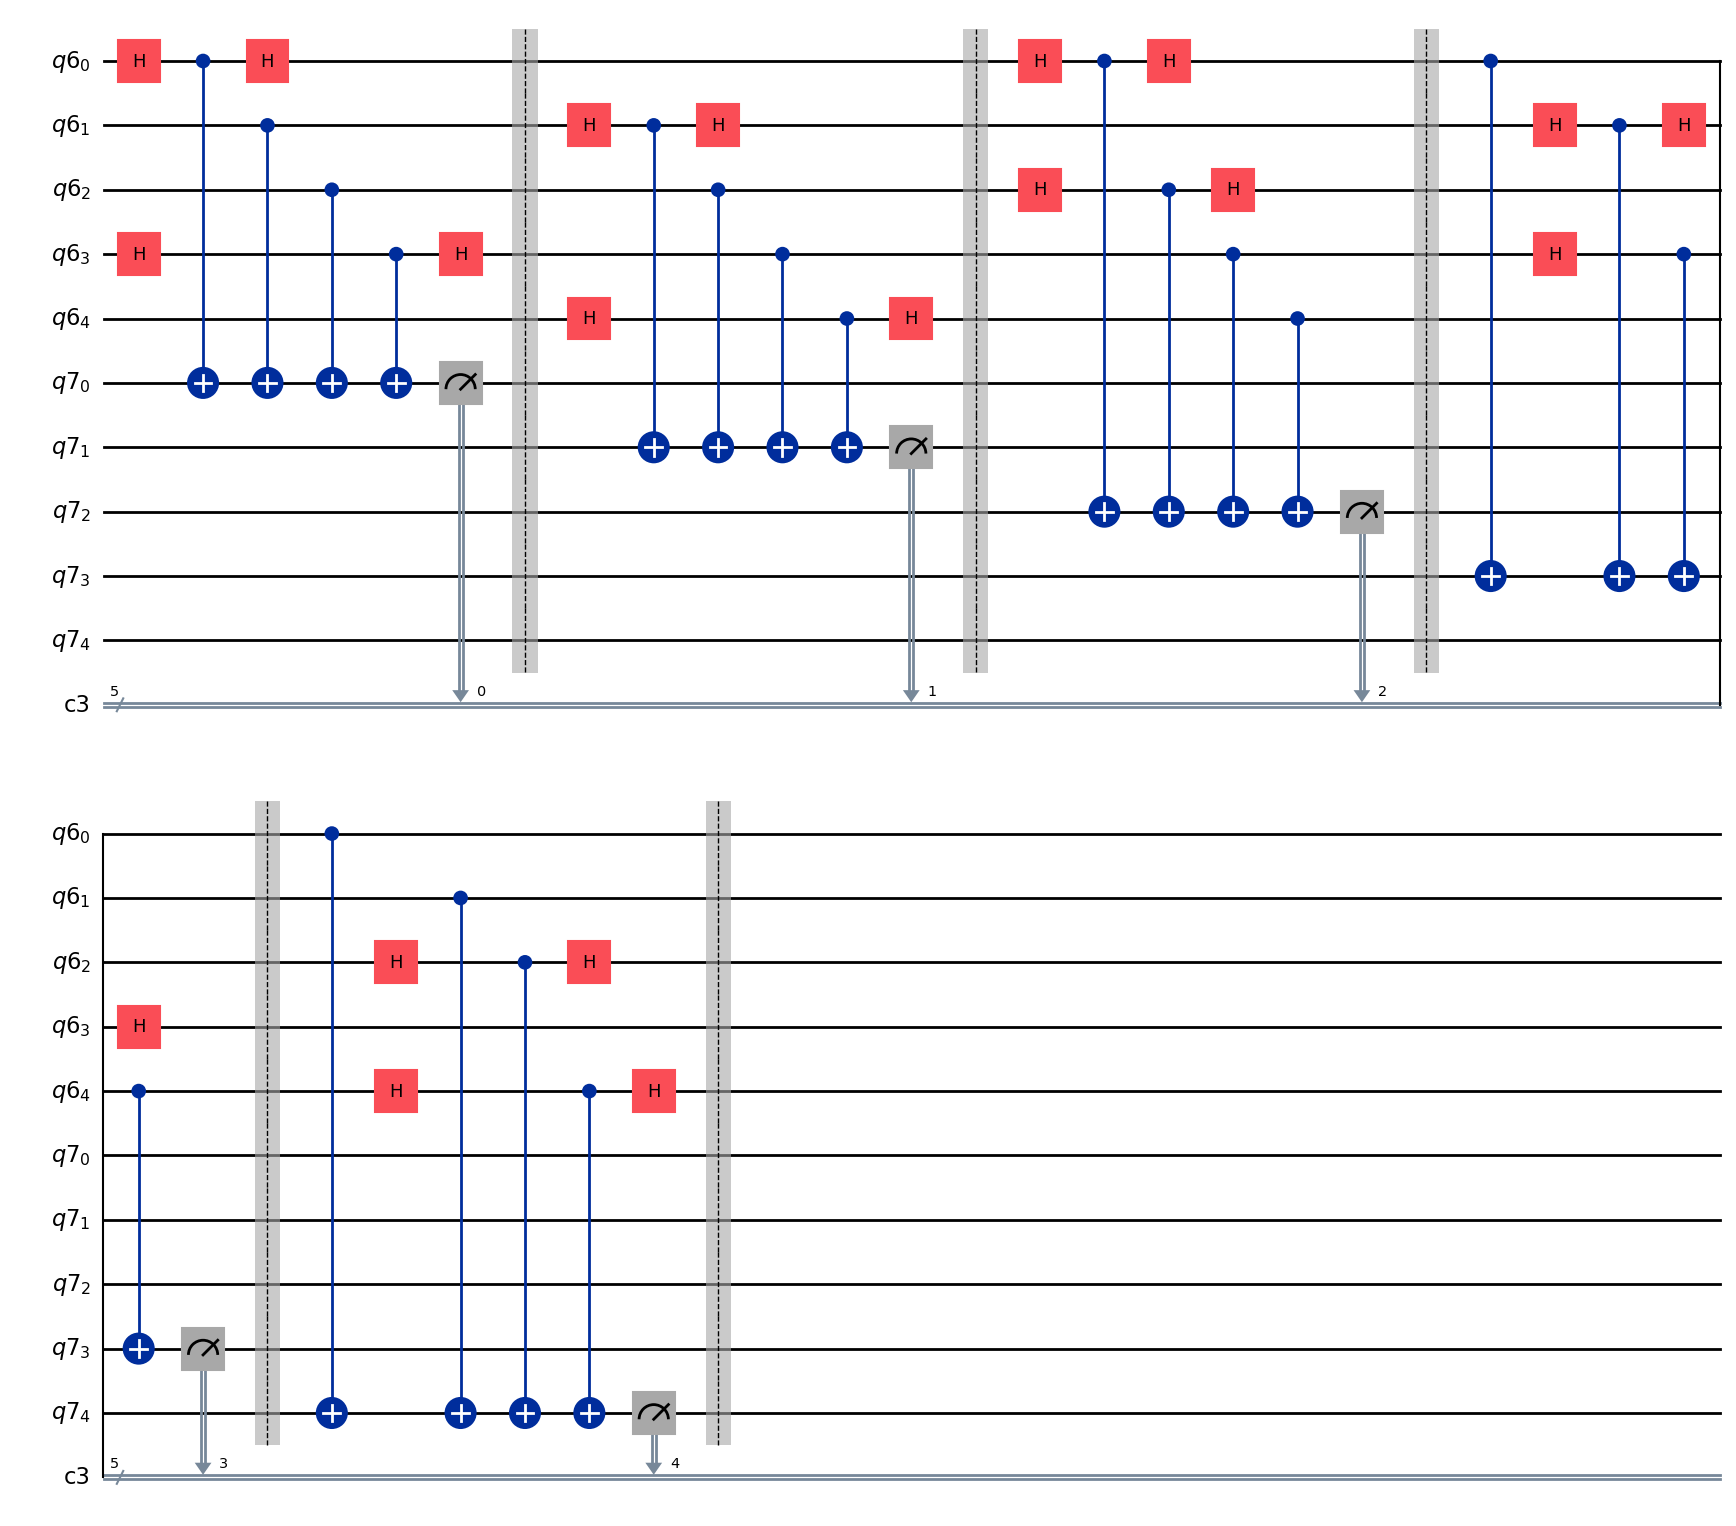

In [28]:
def measure_all_syndromes(data, ancilla, creg):
  assert len(data) == 5
  assert len(ancilla) == 5
  assert len(creg) == 5
  qc = QuantumCircuit(data, ancilla, creg)
  stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ", "ZZXIX"]
  for i in range(5):
    qc.compose(
      exercises.measure_one_syndrome(data, ancilla[i:i+1], creg[i:i+1], stabilizers[i]),
      data[:] + ancilla[i:i+1], creg[i:i+1],
      inplace=True)
    qc.barrier()
  return qc

data = QuantumRegister(5)
ancilla = QuantumRegister(5)
creg = ClassicalRegister(5)

measure_all_syndromes(data, ancilla, creg).draw("mpl")

Next, we apply corrections.
Fortunately, as there are only $3\times 5 = 15$ possible single-qubit errors, we can hard-wire all of them for now.
We write down which Pauli error corresponds to which syndrome.
For example, if there is an $X$ error occuring on first wire, then it'll be caught by syndromes 4 and 5.

In [29]:
exercises.error_to_syndrome("X", 1)

'00011'

Now we loop through all possible 15 errors, and correct all of them.

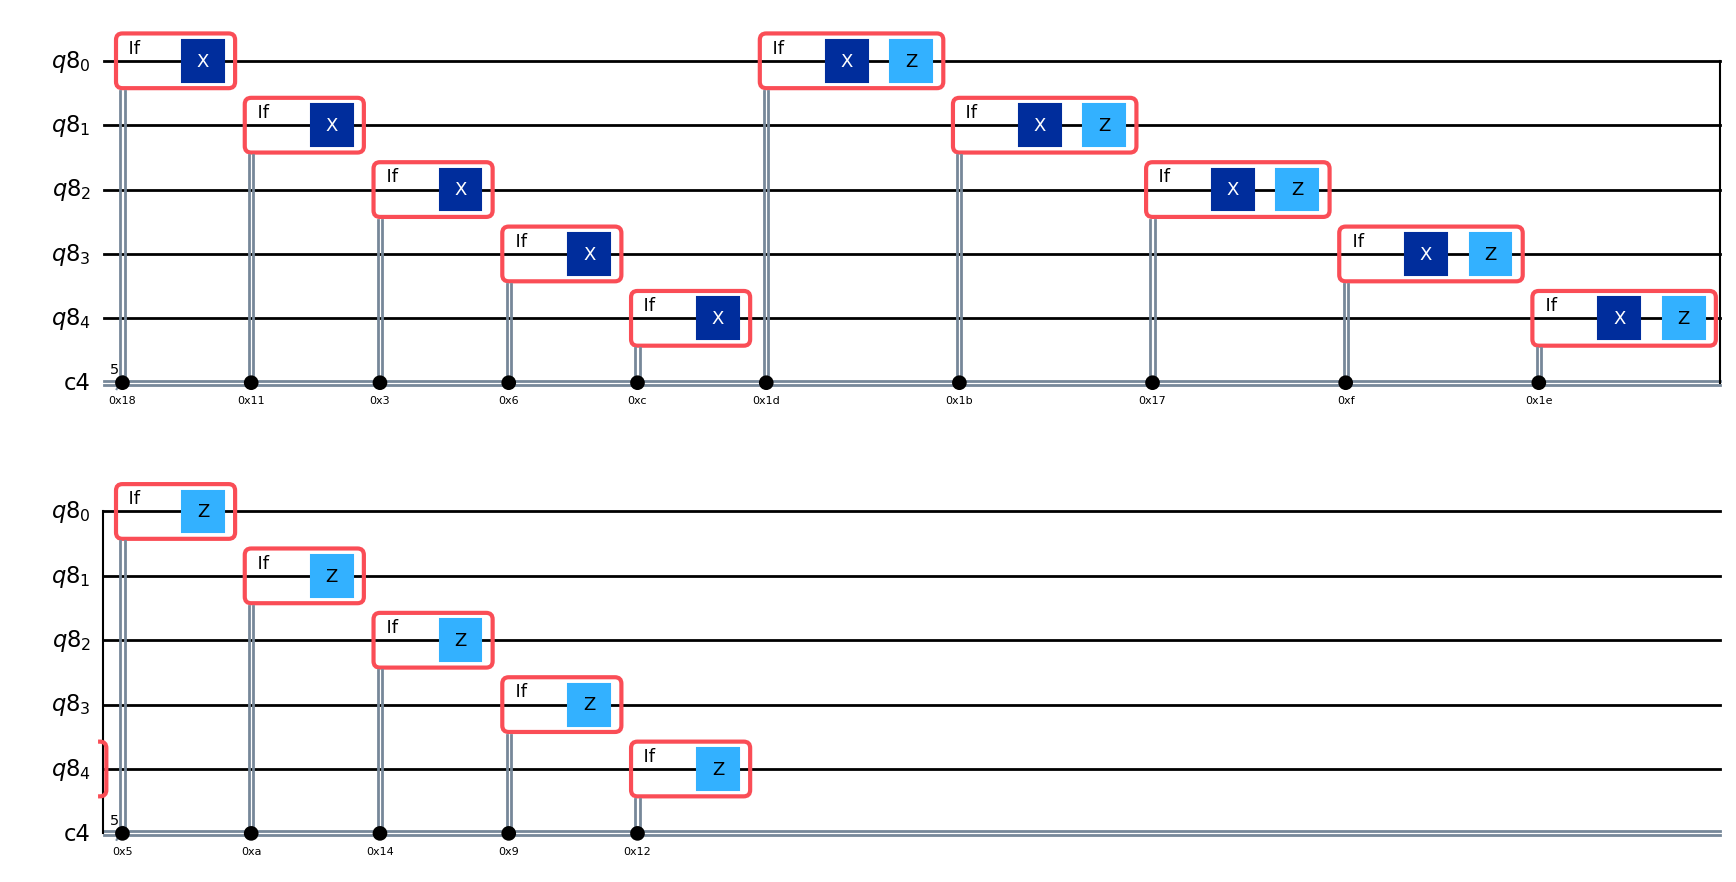

In [30]:
def correct_using_syndrome(data, creg):
  qc = QuantumCircuit(data, creg)
  for pauli, wire in itertools.product(["X", "XZ", "Z"], range(1, 6)):
    error = exercises.error_to_syndrome(pauli, wire)
    error_val = int("".join(reversed(error)), 2)
    with qc.if_test((creg, error_val)):
      if pauli == "X":
        qc.x(data[wire - 1])
      elif pauli == "XZ":
        qc.x(data[wire - 1])
        qc.z(data[wire - 1])
      else:
        assert pauli == "Z"
        qc.z(data[wire - 1])
  return qc

data = QuantumRegister(5)
creg = ClassicalRegister(5)

correct_using_syndrome(data, creg).draw("mpl")

Finally, we glue everything together and hope things work as expected.

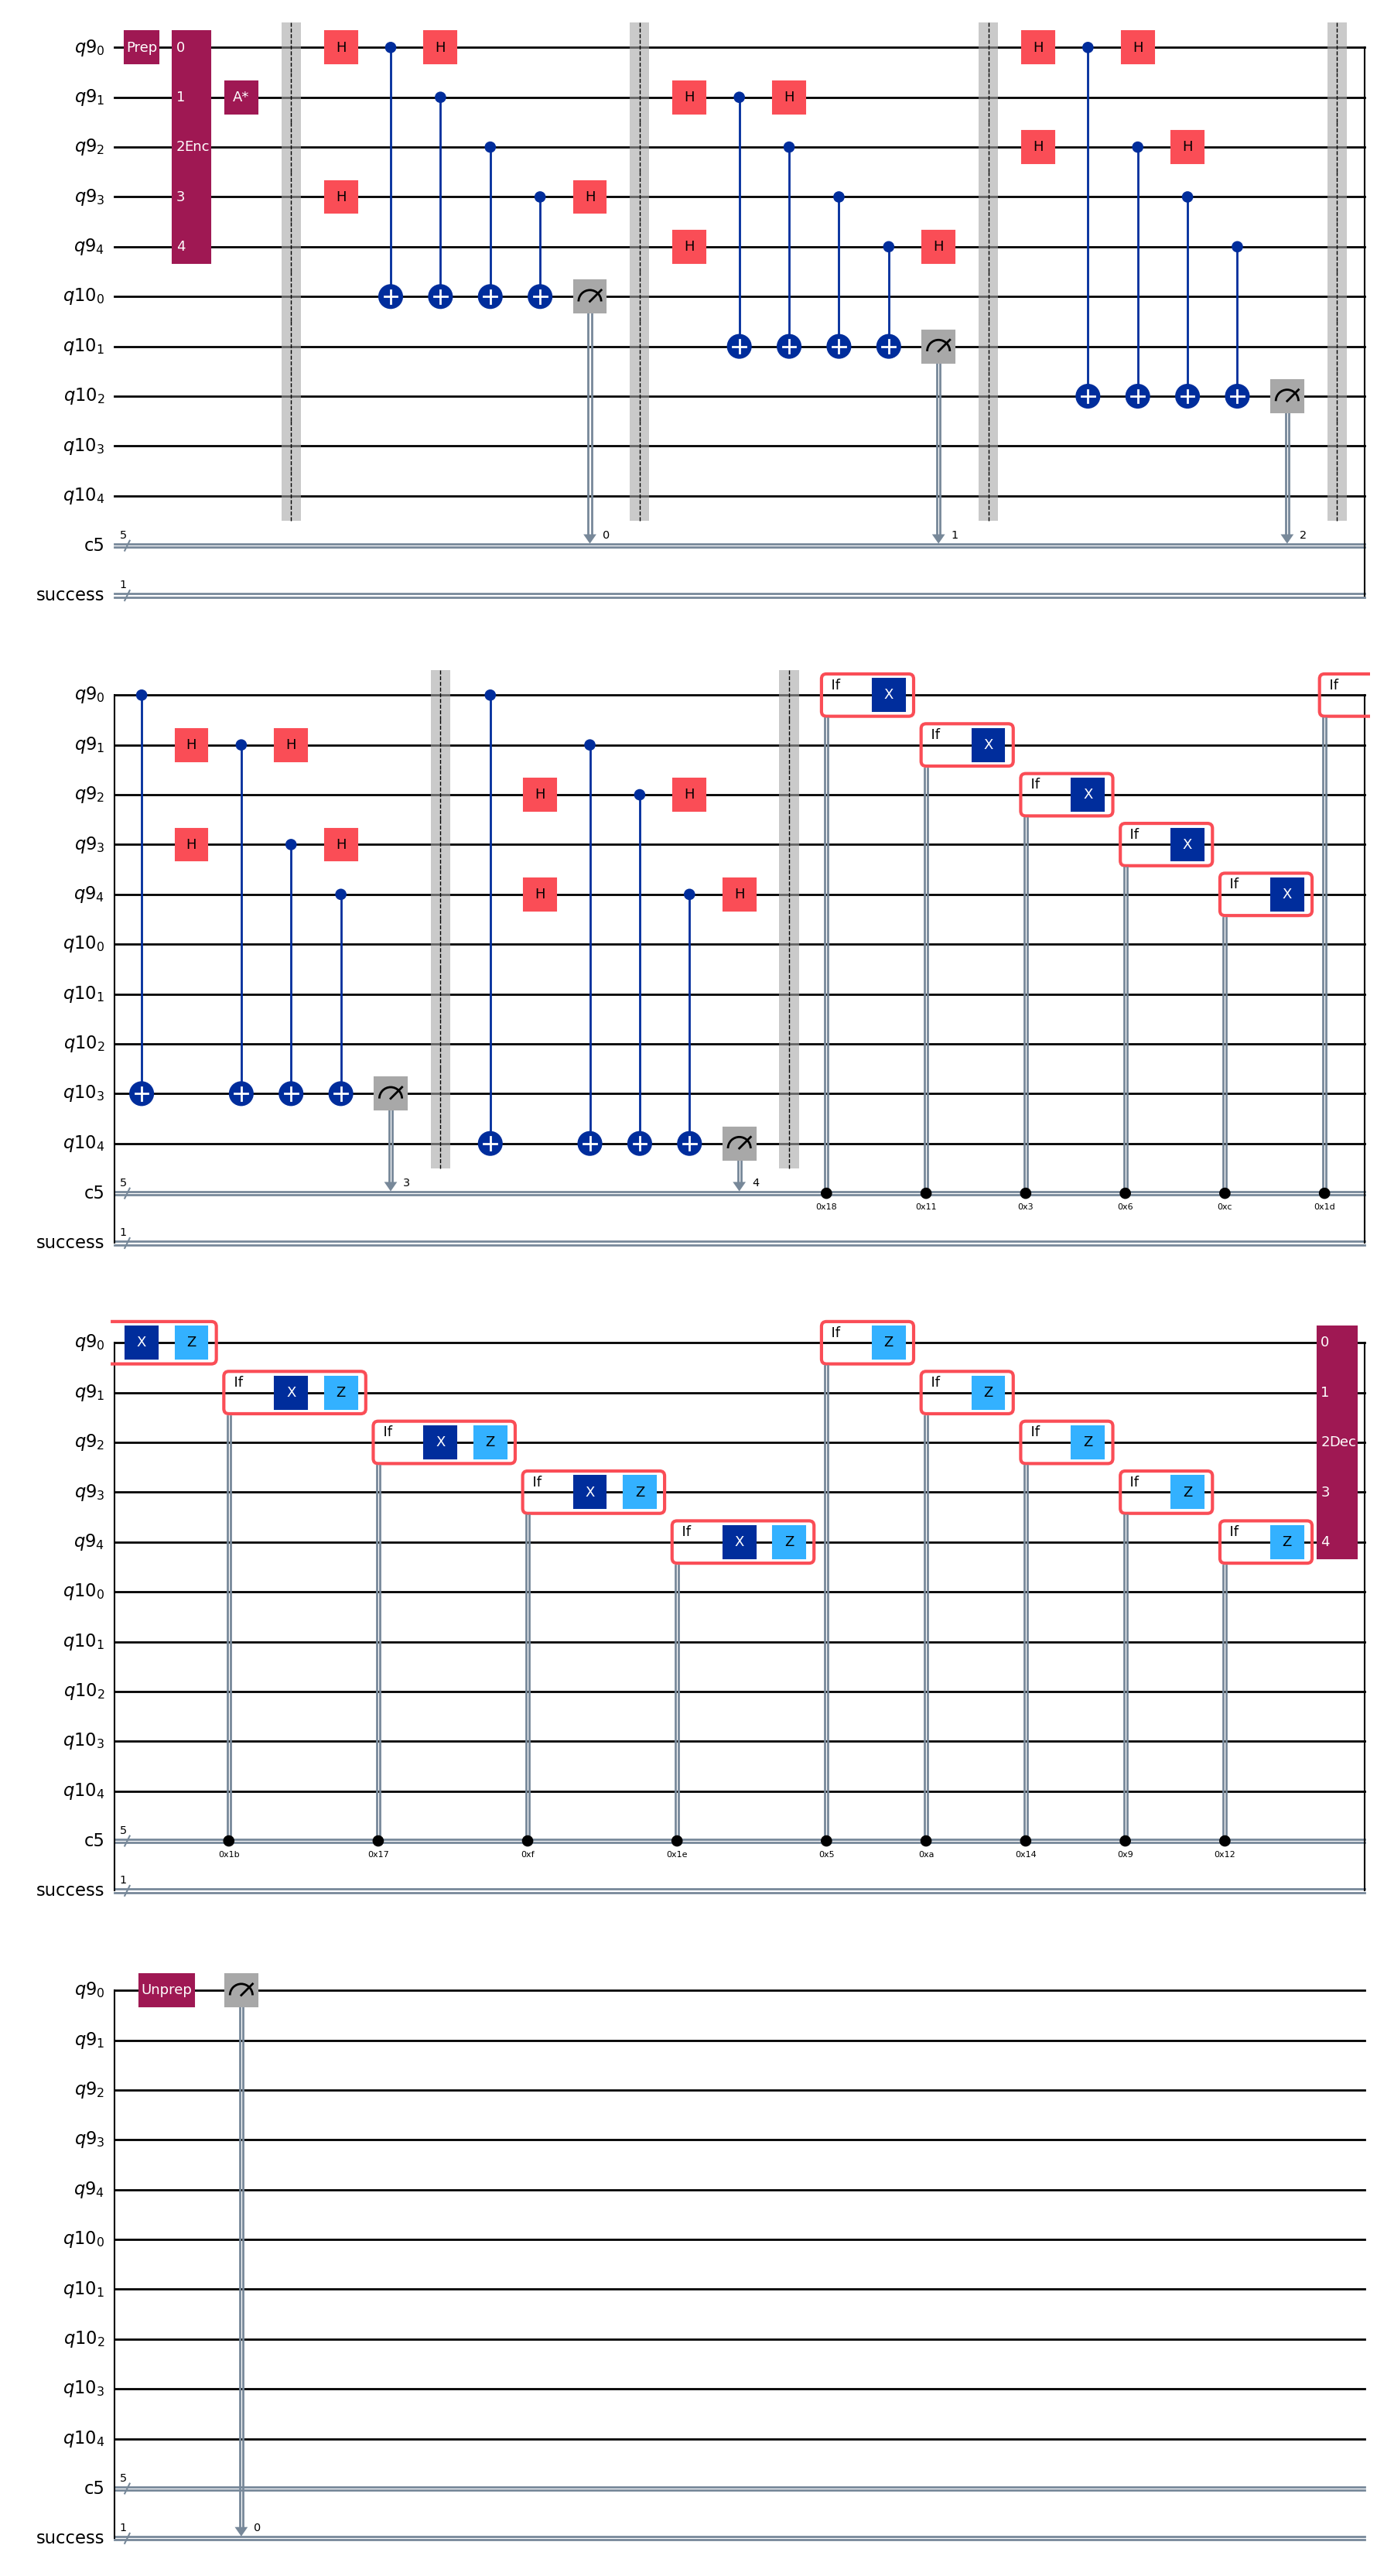

In [31]:
def qec_experiment():
  data = QuantumRegister(5)
  ancilla = QuantumRegister(5)
  creg = ClassicalRegister(5)
  success = ClassicalRegister(1, name="success")
  qc = QuantumCircuit(data, ancilla, creg, success)
  # initialize random input
  U = random_unitary(2)
  qc.unitary(U, data[0], label="Prep")
  # 5-qubit code encode
  qc.unitary(qec_encode, data[0:5], label="Enc")
  # random error
  error_wire = random.randint(0, 4)
  A = random_unitary(2)
  qc.unitary(A, data[error_wire], label="A*")
  qc.barrier()
  # error correction
  qc.compose(measure_all_syndromes(data, ancilla, creg),
    data[:] + ancilla[:], creg,
    inplace=True)
  qc.compose(correct_using_syndrome(data, creg),
    data, creg, inplace=True)
  # decode
  qc.unitary(qec_decode, data[0:5], label="Dec")
  # check success
  qc.unitary(U.adjoint(), data[0], label="Unprep")
  qc.measure(data[0], success)
  return qc

qec_experiment().draw("mpl")

Now, the moment of truth...

In [32]:
sim = AerSimulator()
result = sim.run(qec_experiment(), shots=1000).result()
counts = result.get_counts()
print(counts)

{'0 11011': 523, '0 00000': 19, '0 10001': 239, '0 01010': 219}
